<a href="https://colab.research.google.com/github/othman787/hello-world/blob/master/Financial_Analytics_final_Companion_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Financial Analytics — Companion Notebook
**Data:** `tadawul_merged.csv` — Tadawul-listed company financials, 2006–2026 (annual).
Includes income statement, balance sheet, cash flow, and company profile (name, sector) columns — 161 columns in total.

This notebook mirrors the course slides, using our uploaded data.


## Day 1 (AM) — Load & Inspect

Uploading Files to Colab

Several ways to upload files to your Google Colab environment:

1.  **Using the File Browser (manual upload):**
    *   On the left sidebar, click on the folder icon to open the file browser.
    *   Click on the "Upload to session storage" icon (a page with an arrow pointing up).
    *   Select your `tadawul_merged.csv` file from your local machine.
    *   **Note:** Files uploaded this way are temporary and will be deleted when your Colab session ends.

2.  **Using `files.upload()` (programmatic upload):**
    *   Run the Python code below. It will display an "Upload" button.
    *   Click the button and select your `tadawul_merged.csv` file.
    *   This is also temporary, but useful for scripting.

3.  **Mounting Google Drive:**
    *   If your file is in Google Drive, you can mount your Drive to Colab. This provides more persistent storage.
    *   Run `from google.colab import drive; drive.mount('/content/drive')` and follow the authentication steps.
    *   Your files will then be accessible at `/content/drive/My Drive/your_file_path`.

In [ ]:
# Upload the tadawul_merged.csv file via Colab's file picker
from google.colab import files
import io

# This will open a file picker dialog for you to upload the file.
print("Please upload the 'tadawul_merged.csv' file.")
uploaded = files.upload()

# To verify the upload, you can print the keys (filenames) of the uploaded dictionary
for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Please upload the 'tadawul_merged.csv' file.


Saving tadawul_merged.csv to tadawul_merged.csv
User uploaded file "tadawul_merged.csv" with length 4730200 bytes


In [ ]:
# Load the uploaded CSV into a DataFrame and set a readable number format
import pandas as pd
import matplotlib.pyplot as plt

# To load the file into a DataFrame after uploading with this method:
df = pd.read_csv("tadawul_merged.csv")
pd.options.display.float_format = '{:,.2f}'.format

In [ ]:
# Preview the first 5 rows of the dataset
df.head()

,ticker,fiscal_year,period_type,period_label,period_end_date,currency,profile_name,profile_sector,profile_industry,profile_ceo,...,decrease_in_capital_stock,other_financing_activities,cash_from_financing_activities,effect_of_foreign_exchange,net_change_in_cash,free_cash_flow,free_cash_flow_to_firm,free_cash_flow_to_equity,free_cash_flow_per_share,price_to_free_cash_flow
0,1010,2006,annual,FY,12/31/06,SAR,Riyad Bank,Finance,Major banks,Nadir Sami Al-Koraya,...,NaN,"137,712,000.00","68,856,000.00",NaN,"3,896,808,000.00","3,857,137,000.00",NaN,"3,857,196,000.00",2.31,5.44
1,1010,2007,annual,FY,12/31/07,SAR,Riyad Bank,Finance,Major banks,Nadir Sami Al-Koraya,...,NaN,0.00,"-1,987,623,000.00",NaN,"9,177,294,000.00","10,946,889,000.00",NaN,"10,946,889,000.00",6.57,2.82
2,1010,2008,annual,FY,12/31/08,SAR,Riyad Bank,Finance,Major banks,Nadir Sami Al-Koraya,...,NaN,"13,125,000,000.00","10,924,922,000.00",NaN,"-5,725,532,000.00","-2,981,502,000.00",NaN,"-2,981,502,000.00",-0.75,-10.67
3,1010,2009,annual,FY,12/31/09,SAR,Riyad Bank,Finance,Major banks,Nadir Sami Al-Koraya,...,NaN,"-2,014,593,000.00","-2,014,593,000.00",NaN,"12,768,858,000.00","5,003,879,000.00",NaN,"5,003,879,000.00",1.25,8.06
4,1010,2010,annual,FY,12/31/10,SAR,Riyad Bank,Finance,Major banks,Nadir Sami Al-Koraya,...,NaN,0.00,"-2,059,250,000.00",NaN,"-1,608,233,000.00","1,452,523,000.00",NaN,"1,452,523,000.00",0.36,27.47


In [ ]:
# Preview key identifying and financial columns
df[["ticker", "fiscal_year", "profile_name", "profile_sector", "revenue", "net_income"]].head()

,ticker,fiscal_year,profile_name,profile_sector,revenue,net_income
0,1010,2006,Riyad Bank,Finance,"5,169,329,000.00","2,908,554,000.00"
1,1010,2007,Riyad Bank,Finance,"5,831,599,000.00","3,011,246,000.00"
2,1010,2008,Riyad Bank,Finance,"6,506,553,000.00","2,638,757,000.00"
3,1010,2009,Riyad Bank,Finance,"5,789,673,000.00","3,030,485,000.00"
4,1010,2010,Riyad Bank,Finance,"6,104,329,000.00","2,824,627,000.00"


In [ ]:
# Inspect column names, types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3977 entries, 0 to 3976
Columns: 161 entries, ticker to price_to_free_cash_flow
dtypes: float64(144), int64(2), object(15)
memory usage: 4.9+ MB


In [ ]:
# Get summary statistics for every numeric column
df.describe()

,ticker,fiscal_year,profile_founded,profile_number_of_employees,profile_reporting_calendar.current_fiscal_year,revenue,cost_of_goods_sold,gross_profit,other_operating_income,operating_expenses_total,...,decrease_in_capital_stock,other_financing_activities,cash_from_financing_activities,effect_of_foreign_exchange,net_change_in_cash,free_cash_flow,free_cash_flow_to_firm,free_cash_flow_to_equity,free_cash_flow_per_share,price_to_free_cash_flow
count,"3,977.00","3,977.00","3,955.00","3,907.00","3,972.00","3,898.00","3,143.00","3,166.00","3,156.00","3,467.00",...,277.00,"3,741.00","3,741.00",499.00,"3,735.00","3,915.00","3,027.00","3,915.00","3,914.00","3,541.00"
mean,"4,627.03","2,017.95","1,990.66","3,217.61","2,025.02","7,052,709,208.35","4,398,803,179.81","3,591,878,345.66","7,065,324.73","906,221,709.57",...,"-114,495,528.42","-25,741,617.67","-845,255,205.39","-15,742,837.76","99,657,399.53","1,477,878,836.01","1,095,611,609.92","1,651,791,443.39",0.25,-303.48
std,"2,725.90",5.63,19.68,"7,975.39",0.15,"76,337,790,237.13","37,282,513,003.02","49,026,348,947.59","300,256,823.23","8,549,558,502.46",...,"496,593,288.06","2,150,720,040.52","16,677,521,627.65","233,590,485.83","3,250,236,240.54","23,783,581,047.74","55,334,376,373.26","22,993,718,457.83",45.71,"16,205.97"
min,"1,010.00","2,006.00","1,830.00",4.00,"2,025.00","-123,451,429.00","-1,221,520,986.00","-1,755,344,000.00","-6,531,827,000.00","-4,230,235,000.00",...,"-5,368,352,880.00","-42,419,000,000.00","-510,869,000,000.00","-997,528,000.00","-73,532,000,000.00","-85,871,087,000.00","-2,647,120,000,000.00","-85,865,796,000.00","-2,839.84","-710,862.29"
25%,"2,250.00","2,014.00","1,979.00",228.00,"2,025.00","167,649,373.25","103,469,680.00","37,324,578.75",0.00,"21,954,105.00",...,"-43,847,000.00","-38,059,038.00","-146,138,000.00","-5,050,503.50","-26,194,627.00","-10,708,896.00","-26,728.45","-2,498,629.50",-0.22,-8.96
50%,"4,110.00","2,019.00","1,992.00",700.00,"2,025.00","653,761,175.50","465,938,351.00","152,290,261.50",0.00,"71,739,000.00",...,"-248,667.00","-2,750,000.00","-15,488,455.00","-124,433.00","572,157.00","31,585,367.00","57,982,014.64","37,973,000.00",0.53,10.20
75%,"7,020.00","2,023.00","2,006.00","2,800.00","2,025.00","1,917,683,973.75","1,232,601,273.00","486,959,975.75",0.00,"277,892,983.00",...,0.00,0.00,"12,684,747.00","219,488.50","39,778,195.00","191,256,344.50","283,450,983.50","223,721,385.50",2.10,23.39
max,"9,651.00","2,026.00","2,022.00","76,664.00","2,026.00","2,266,370,000,000.00","911,916,000,000.00","1,582,150,000,000.00","14,058,130,000.00","438,076,000,000.00",...,0.00,"42,316,765,000.00","46,778,668,000.00","4,487,827,000.00","101,910,000,000.00","698,152,000,000.00","702,805,000,000.00","574,720,000,000.00",66.40,"281,109.65"


In [ ]:
# Check the dataset's row and column count
df.shape

(3977, 161)

## Day 1 (AM) — Data Quality Check
Before any analysis: how big is this file, what type is every column, does it repeat itself,
what's missing, and does anything look like an outlier?

In [ ]:
# Data quality check: shape, column types, and duplicate rows
print("Shape:", df.shape)
dtype_counts = {str(k): int(v) for k, v in df.dtypes.value_counts().items()}
print("Column types:", dtype_counts)

print("\nExact duplicate rows:", df.duplicated().sum())
key_dupes = df.duplicated(subset=["ticker", "fiscal_year"])
print("Duplicate ticker+year rows:", key_dupes.sum())

Shape: (3977, 161)
Column types: {'float64': 144, 'object': 15, 'int64': 2}

Exact duplicate rows: 0
Duplicate ticker+year rows: 14


In [ ]:
# Data quality check: fully empty columns and outlier range (min/median/max)
fully_empty = df.isna().all()
print("Completely empty columns:", fully_empty.sum())

cols = ["revenue", "bs_total_equity"]
(df[cols]).describe().loc[["min", "50%", "max"]].round(2)

Completely empty columns: 21


,revenue,bs_total_equity
min,"-123,451,429.00","-1,466,203,430.00"
50%,"653,761,175.50","705,932,072.00"
max,"2,266,370,000,000.00","1,737,090,000,000.00"


In [ ]:
# Report each column's non-missing row count and coverage percentage
print("Column Name | Non-Missing Rows | Coverage (%)")

print("--------------------------------------------------")
for col in df.columns:
    non_missing_count = df[col].count()
    total_rows = df.shape[0]
    coverage_percentage = (non_missing_count / total_rows) * 100
    print(f"{col:<20} | {non_missing_count:<17} | {coverage_percentage:.2f}%")

Column Name | Non-Missing Rows | Coverage (%)
--------------------------------------------------
ticker               | 3977              | 100.00%
fiscal_year          | 3977              | 100.00%
period_type          | 3974              | 99.92%
period_label         | 3974              | 99.92%
period_end_date      | 3977              | 100.00%
currency             | 3974              | 99.92%
profile_name         | 3977              | 100.00%
profile_sector       | 3977              | 100.00%
profile_industry     | 3977              | 100.00%
profile_ceo          | 3914              | 98.42%
profile_founded      | 3955              | 99.45%
profile_website      | 3977              | 100.00%
profile_number_of_employees | 3907              | 98.24%
profile_short_description | 3977              | 100.00%
profile_address.city | 3977              | 100.00%
profile_address.country | 3977              | 100.00%
profile_ipo.date     | 3977              | 100.00%
profile_reporting_calendar.

In [ ]:
# Inspect the actual duplicate ticker+year rows
dupe_mask = df.duplicated(subset=["ticker", "fiscal_year"], keep=False)
df[dupe_mask].sort_values(["ticker", "fiscal_year"])[
    ["ticker", "fiscal_year", "period_end_date", "revenue", "bs_total_equity"]
].head(28)

,ticker,fiscal_year,period_end_date,revenue,bs_total_equity
1870,4070,2010,12/31/10,"153,903,651.00","262,759,986.00"
1871,4070,2010,3/31/10,"117,763,000.00","226,966,000.00"
1872,4070,2011,12/31/11,"121,681,183.00","234,516,905.00"
1873,4070,2011,3/31/11,NaN,"248,664,000.00"
1961,4100,2011,3/31/11,NaN,"3,442,203,579.00"
1962,4100,2011,4/30/11,"323,995,151.00","3,442,204,000.00"
1963,4100,2012,1/31/12,NaN,NaN
1964,4100,2012,3/31/12,NaN,"3,747,929,257.00"
1965,4100,2012,4/30/12,"368,228,735.00","3,747,929,257.00"
1966,4100,2013,1/31/13,NaN,NaN


In [ ]:
# Look up company names for a specific set of tickers
df[df['ticker'].isin([4100, 4070, 4191,4240,4291,4335 ])]['profile_name'].unique()

array(['Tihama Advertising & Public Relations Co.',
       'Makkah Construction & Development Co.',
       'Abdullah Saad Mohammed Abo Moati for Bookstores Co.',
       'AFG International Company',
       'National Co. for Learning & Education', 'Musharaka REIT Fund'],
      dtype=object)

**Addtional Ways to Data Quality Check**

In [ ]:
# Check missing values and min/median/max for selected columns
columns_to_analyze = [
    "decrease_in_capital_stock",
    "effect_of_foreign_exchange",
    "cash_from_divestitures"
]

print("--- Missing Values and Descriptive Statistics ---")
for col in columns_to_analyze:
    missing_count = df[col].isnull().sum()
    total_count = df.shape[0]
    missing_percentage = (missing_count / total_count) * 100

    print(f"\nColumn: {col}")
    print(f"  Missing Values: {missing_count} ({missing_percentage:.2f}%)")
    if missing_count < total_count: # Only calculate stats if there's actual data
        print(f"  Min: {df[col].min():.2f}")
        print(f"  Median: {df[col].median():.2f}")
        print(f"  Max: {df[col].max():.2f}")
    else:
        print("  No non-missing data to calculate min/median/max.")

--- Missing Values and Descriptive Statistics ---

Column: decrease_in_capital_stock
  Missing Values: 3700 (93.03%)
  Min: -5368352880.00
  Median: -248667.00
  Max: 0.00

Column: effect_of_foreign_exchange
  Missing Values: 3478 (87.45%)
  Min: -997528000.00
  Median: -124433.00
  Max: 4487827000.00

Column: cash_from_divestitures
  Missing Values: 3559 (89.49%)
  Min: -22168000.00
  Median: 1016130.00
  Max: 30116000000.00


In [ ]:
# Define a reusable function to report missing values and stats for any column
def column_report(df, columns_to_analyze):
    """
    Reports missing values and descriptive statistics (min, median, max)
    for a given list of columns in a DataFrame.

    Args:
        df (pd.DataFrame): The input DataFrame.
        columns_to_analyze (list): A list of column names to analyze.
    """
    print("--- Missing Values and Descriptive Statistics ---")
    for col in columns_to_analyze:
        missing_count = df[col].isnull().sum()
        total_count = df.shape[0]
        missing_percentage = (missing_count / total_count) * 100

        print(f"\nColumn: {col}")
        print(f"  Missing Values: {missing_count} ({missing_percentage:.2f}%)")
        # Only calculate stats if there's actual non-missing data
        if missing_count < total_count:
            print(f"  Min: {df[col].min():.2f}")
            print(f"  Median: {df[col].median():.2f}")
            print(f"  Max: {df[col].max():.2f}")
        else:
            print("  No non-missing data to calculate min/median/max.")

# Example usage with the same columns as before:
# column_report(df, ["decrease_in_capital_stock", "effect_of_foreign_exchange", "cash_from_divestitures"])

In [ ]:
# Run the column_report function on the revenue column
column_report(df, ["revenue"])

--- Missing Values and Descriptive Statistics ---

Column: revenue
  Missing Values: 79 (1.99%)
  Min: -123451429.00
  Median: 653761175.50
  Max: 2266370000000.00


## Day 1 (PM) — Select, Filter, Groupby, Chart

In [ ]:
# .loc selects by label
df.loc[:, "revenue"]

,revenue
0,"5,169,329,000.00"
1,"5,831,599,000.00"
2,"6,506,553,000.00"
3,"5,789,673,000.00"
4,"6,104,329,000.00"
...,...
3972,"710,987,000.00"
3973,"166,005,066.00"
3974,"197,645,932.00"
3975,"124,407,393.00"


In [ ]:
# .iloc selects by position
df.iloc[0:5, 0:3]

,ticker,fiscal_year,period_type
0,1010,2006,annual
1,1010,2007,annual
2,1010,2008,annual
3,1010,2009,annual
4,1010,2010,annual


In [ ]:
# Boolean filter: firms in the Finance sector
df["profile_sector"] == "Finance"

,profile_sector
0,True
1,True
2,True
3,True
4,True
...,...
3972,False
3973,False
3974,False
3975,False


In [ ]:
# Combine two conditions: large revenue AND positive net income
big_and_profitable = df[
    (df["revenue"] > 1_000_000_000) & (df["net_income"] > 0)
 ]

(df["revenue"] > 1_000_000_000) & (df["net_income"] > 0)
big_and_profitable.shape

(1353, 161)

In [ ]:
# groupby: average revenue by sector and year
avg_by_sector_and_year = (df
    .groupby(["profile_sector", "fiscal_year"])
    ["revenue"]
    .agg("mean")
    .sort_index()
    .round(0)
)
avg_by_sector_and_year.head(10).round(0)

profile_sector       fiscal_year
Commercial services  2006            530,997,000.00
                     2007            534,446,667.00
                     2008            647,951,333.00
                     2009            489,210,667.00
                     2010            435,235,163.00
                     2011            534,351,701.00
                     2012            790,453,243.00
                     2013          1,433,911,048.00
                     2014          1,487,797,933.00
                     2015          1,296,583,798.00
Name: revenue, dtype: float64

In [ ]:
# groupby: median revenue by sector, most recent year
med_by_sector = (
    df[df["fiscal_year"] == 2025]
    .groupby("profile_sector")["revenue"]
    .median()
    .sort_values(ascending=False)
)
med_by_sector.head(10).round(0)

,revenue
profile_sector,
Energy minerals,"35,008,493,000.00"
Communications,"6,222,699,985.00"
Utilities,"5,100,847,616.00"
Transportation,"1,826,576,000.00"
Industrial services,"1,440,334,174.00"
Consumer durables,"1,276,996,936.00"
Health technology,"1,171,420,498.00"
Retail trade,"887,752,858.00"
Non-energy minerals,"735,557,522.00"


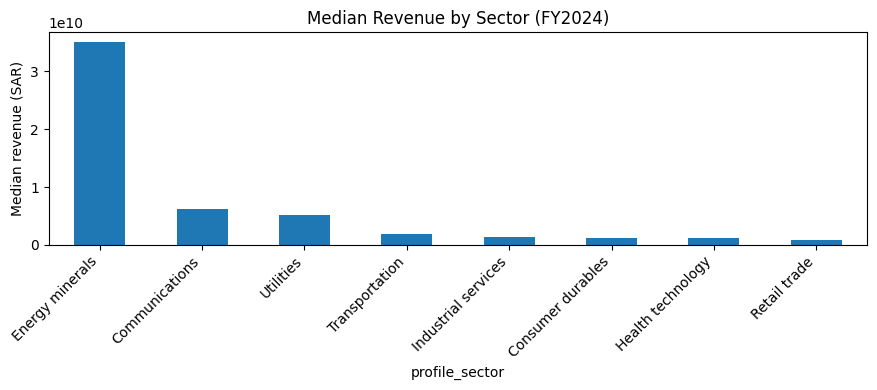

In [ ]:
# Plot median revenue by sector as a bar chart
med_by_sector.head(8).plot(kind="bar", title="Median Revenue by Sector (FY2024)", figsize=(9,4))
plt.ylabel("Median revenue (SAR)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Day 2 (AM) — Reshaping & the Firm × Year Index

In [ ]:
# Reshape long to wide: revenue by ticker x year
wide = df.pivot_table(index="ticker", columns="fiscal_year", values="revenue")
wide.iloc[:, 3:].round(0)

fiscal_year,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
ticker,,,,,,,,,,,,,,,,,,
1010,"5,789,673,000.00","6,104,329,000.00","6,275,801,000.00","6,916,265,000.00","7,096,022,000.00","8,011,766,000.00","7,944,354,000.00","7,602,280,000.00","8,125,141,000.00","8,925,696,000.00","10,722,812,000.00","11,086,100,000.00","11,575,571,000.00","13,328,144,000.00","15,758,743,000.00","17,252,501,000.00","18,354,127,000.00",NaN
1020,"1,171,401,000.00","1,212,952,000.00","1,172,257,000.00","1,583,087,000.00","1,829,636,000.00","2,227,129,000.00","2,918,222,000.00","2,472,732,000.00","2,579,696,000.00","2,664,577,000.00","2,976,943,000.00","3,280,614,000.00","3,546,884,000.00","3,429,643,000.00","3,323,080,000.00","3,779,125,000.00","4,462,516,000.00",NaN
1030,"1,957,121,000.00","1,748,816,000.00","1,530,880,000.00","1,652,602,000.00","1,992,665,000.00","2,521,176,000.00","2,240,625,000.00","2,111,605,000.00","2,551,261,000.00","2,712,760,000.00","2,864,049,000.00","2,844,407,000.00","2,758,248,000.00","3,281,043,000.00","3,952,869,000.00","4,163,871,000.00","4,778,483,000.00",NaN
1050,"3,877,684,000.00","4,195,571,000.00","4,584,477,000.00","4,975,306,000.00","4,994,562,000.00","5,676,934,000.00","6,220,108,000.00","6,313,950,000.00","6,316,328,000.00","6,342,637,000.00","6,853,108,000.00","7,098,875,000.00","7,244,825,000.00","8,021,256,000.00","9,398,142,000.00","9,621,734,000.00","10,485,949,000.00",NaN
1060,"4,719,346,000.00","4,581,142,000.00","4,905,333,000.00","5,168,072,000.00","5,745,812,000.00","6,503,158,000.00","6,640,258,000.00","6,859,064,000.00","7,078,053,000.00","7,340,528,000.00","9,204,982,000.00","8,863,331,000.00","7,683,267,000.00","9,654,205,000.00","12,814,086,000.00","14,136,138,000.00","14,841,606,000.00",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9647,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"54,787,529.00","84,927,406.00",NaN
9648,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"89,228,206.00","43,293,893.00",NaN
9649,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"565,650,000.00","612,246,000.00","710,987,000.00",NaN


In [ ]:
# Reshape wide to long: melt revenue back into one row per ticker-year
long = df.melt(id_vars=["ticker", "fiscal_year"], value_vars=["revenue"])
long = long.rename(columns={"value": "revenue"}).drop(columns=["variable"])
long.head(10)

,ticker,fiscal_year,revenue
0,1010,2006,"5,169,329,000.00"
1,1010,2007,"5,831,599,000.00"
2,1010,2008,"6,506,553,000.00"
3,1010,2009,"5,789,673,000.00"
4,1010,2010,"6,104,329,000.00"
5,1010,2011,"6,275,801,000.00"
6,1010,2012,"6,916,265,000.00"
7,1010,2013,"7,096,022,000.00"
8,1010,2014,"8,011,766,000.00"
9,1010,2015,"7,944,354,000.00"


In [ ]:
# pivot_table: revenue by ticker x year, for a handful of tickers
sample_tickers = [1010, 1020, 1030, 1050, 1060]
wide_view = df[df["ticker"].isin(sample_tickers)].pivot_table(
    index="ticker", columns="fiscal_year", values="revenue"
)
wide_view.iloc[:, -5:].round(0)

fiscal_year,2021,2022,2023,2024,2025
ticker,,,,,
1010,"11,575,571,000.00","13,328,144,000.00","15,758,743,000.00","17,252,501,000.00","18,354,127,000.00"
1020,"3,546,884,000.00","3,429,643,000.00","3,323,080,000.00","3,779,125,000.00","4,462,516,000.00"
1030,"2,758,248,000.00","3,281,043,000.00","3,952,869,000.00","4,163,871,000.00","4,778,483,000.00"
1050,"7,244,825,000.00","8,021,256,000.00","9,398,142,000.00","9,621,734,000.00","10,485,949,000.00"
1060,"7,683,267,000.00","9,654,205,000.00","12,814,086,000.00","14,136,138,000.00","14,841,606,000.00"


In [ ]:
# Multi-index: ticker x fiscal_year -- slice one firm's full history
panel = df.set_index(["ticker", "fiscal_year"]).sort_index()
panel.loc[1010, ["profile_name", "revenue", "net_income"]].tail(5)

,profile_name,revenue,net_income
fiscal_year,,,
2021,Riyad Bank,"11,575,571,000.00","6,025,379,000.00"
2022,Riyad Bank,"13,328,144,000.00","7,019,322,000.00"
2023,Riyad Bank,"15,758,743,000.00","8,045,844,000.00"
2024,Riyad Bank,"17,252,501,000.00","9,321,894,000.00"
2025,Riyad Bank,"18,354,127,000.00","10,410,951,000.00"


In [ ]:
# View one firm's full history using the multi-index
panel.loc[1010]

,period_type,period_label,period_end_date,currency,profile_name,profile_sector,profile_industry,profile_ceo,profile_founded,profile_website,...,decrease_in_capital_stock,other_financing_activities,cash_from_financing_activities,effect_of_foreign_exchange,net_change_in_cash,free_cash_flow,free_cash_flow_to_firm,free_cash_flow_to_equity,free_cash_flow_per_share,price_to_free_cash_flow
fiscal_year,,,,,,,,,,,,,,,,,,,,,
2006,annual,FY,12/31/06,SAR,Riyad Bank,Finance,Major banks,Nadir Sami Al-Koraya,"1,957.00",http://www.riyadbank.com,...,NaN,"137,712,000.00","68,856,000.00",NaN,"3,896,808,000.00","3,857,137,000.00",NaN,"3,857,196,000.00",2.31,5.44
2007,annual,FY,12/31/07,SAR,Riyad Bank,Finance,Major banks,Nadir Sami Al-Koraya,"1,957.00",http://www.riyadbank.com,...,NaN,0.00,"-1,987,623,000.00",NaN,"9,177,294,000.00","10,946,889,000.00",NaN,"10,946,889,000.00",6.57,2.82
2008,annual,FY,12/31/08,SAR,Riyad Bank,Finance,Major banks,Nadir Sami Al-Koraya,"1,957.00",http://www.riyadbank.com,...,NaN,"13,125,000,000.00","10,924,922,000.00",NaN,"-5,725,532,000.00","-2,981,502,000.00",NaN,"-2,981,502,000.00",-0.75,-10.67
2009,annual,FY,12/31/09,SAR,Riyad Bank,Finance,Major banks,Nadir Sami Al-Koraya,"1,957.00",http://www.riyadbank.com,...,NaN,"-2,014,593,000.00","-2,014,593,000.00",NaN,"12,768,858,000.00","5,003,879,000.00",NaN,"5,003,879,000.00",1.25,8.06
2010,annual,FY,12/31/10,SAR,Riyad Bank,Finance,Major banks,Nadir Sami Al-Koraya,"1,957.00",http://www.riyadbank.com,...,NaN,0.00,"-2,059,250,000.00",NaN,"-1,608,233,000.00","1,452,523,000.00",NaN,"1,452,523,000.00",0.36,27.47
2011,annual,FY,12/31/11,SAR,Riyad Bank,Finance,Major banks,Nadir Sami Al-Koraya,"1,957.00",http://www.riyadbank.com,...,NaN,0.00,"-3,801,180,000.00",NaN,"-6,353,268,000.00","612,654,000.00","612,654,000.00","-1,262,396,000.00",0.15,57.04
2012,annual,FY,12/31/12,SAR,Riyad Bank,Finance,Major banks,Nadir Sami Al-Koraya,"1,957.00",http://www.riyadbank.com,...,NaN,0.00,"-2,160,235,000.00",NaN,"7,524,950,000.00","8,346,971,000.00","8,346,971,000.00","8,346,971,000.00",2.09,4.13
2013,annual,FY,12/31/13,SAR,Riyad Bank,Finance,Major banks,Nadir Sami Al-Koraya,"1,957.00",http://www.riyadbank.com,...,NaN,0.00,"1,979,764,000.00",NaN,"-5,999,717,000.00","-1,011,460,000.00","-1,011,460,000.00","2,988,540,000.00",-0.25,-43.30
2014,annual,FY,12/31/14,SAR,Riyad Bank,Finance,Major banks,Nadir Sami Al-Koraya,"1,957.00",http://www.riyadbank.com,...,NaN,0.00,"-2,435,820,000.00",NaN,"4,763,938,000.00","10,247,647,000.00","10,247,647,000.00","10,247,647,000.00",2.56,4.97


In [ ]:
# View all firms for a single year using the multi-index
panel.loc[(slice(None)), 2025,:]

,period_type,period_label,period_end_date,currency,profile_name,profile_sector,profile_industry,profile_ceo,profile_founded,profile_website,...,decrease_in_capital_stock,other_financing_activities,cash_from_financing_activities,effect_of_foreign_exchange,net_change_in_cash,free_cash_flow,free_cash_flow_to_firm,free_cash_flow_to_equity,free_cash_flow_per_share,price_to_free_cash_flow
ticker,,,,,,,,,,,,,,,,,,,,,
1010,annual,FY,12/31/25,SAR,Riyad Bank,Finance,Major banks,Nadir Sami Al-Koraya,"1,957.00",http://www.riyadbank.com,...,"-206,628,000.00","-4,361,029,000.00","30,453,464,000.00",NaN,"-2,757,509,000.00","-25,865,856,000.00","-25,865,856,000.00","14,411,863,000.00",-6.49,-3.14
1020,annual,FY,12/31/25,SAR,Bank Aljazira,Finance,Major banks,Naif Abdulkareem Al-Abdulkareem,"1,975.00",http://www.aljazirabank.com.sa/ar-sa/,...,"-83,190,000.00","2,421,599,000.00","2,323,757,000.00",NaN,"-249,147,000.00","-1,103,839,000.00","-1,103,839,000.00","-1,103,221,000.00",-0.86,-12.89
1030,annual,FY,12/31/25,SAR,Saudi Investment Bank,Finance,Regional banks,Faisal Abdullah Al-Omran,"1,976.00",http://www.saib.com.sa,...,0.00,"-355,154,000.00","1,436,708,000.00",NaN,"-3,551,615,000.00","1,024,799,000.00","1,024,799,000.00","3,814,521,000.00",0.82,15.98
1050,annual,FY,12/31/25,SAR,Banque Saudi Fransi,Finance,Major banks,Bader Al Salloom,"1,977.00",http://www.bsf.sa,...,"-123,893,000.00","-628,455,000.00","19,542,214,000.00",NaN,"-372,430,000.00","-12,730,907,000.00","-12,730,907,000.00","10,259,869,000.00",-5.09,-3.30
1060,annual,FY,12/31/25,SAR,Saudi Awwal Bank,Finance,Major banks,Anthony William Cripps,"1,978.00",http://www.sab.com,...,0.00,"3,666,730,000.00","2,553,343,000.00",NaN,"4,035,554,000.00","6,891,142,000.00","6,891,142,000.00","9,646,807,000.00",3.35,9.66
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9647,annual,FY,12/31/25,SAR,Wajd Life Trading Co.,Distribution services,Medical distributors,Mohammed Issa Yahya Namazi,"2,013.00",http://www.wajdlife.com,...,NaN,"-1,479,742.00","31,401,350.00",NaN,"4,463,994.00","-26,937,356.00",NaN,"-5,956,264.00",-2.52,-2.21
9648,annual,FY,12/31/25,SAR,Hamad Mohammed Bin Saedan Real Estate Co.,Finance,Real estate development,Abdulaziz Hamad Mohammed Bin Saedan,"1,969.00",http://hmbs.boxesic.com,...,NaN,"3,057,848.00","94,752,280.00",NaN,"22,967,599.00","-82,019,141.00","-76,846,901.32","-31,768,420.00",-4.43,-1.74
9649,annual,FY,9/30/25,SAR,Jamjoom Fashion Trading Co.,Retail trade,Apparel/Footwear retail,Stephen Graham Holbrook,"1,992.00",http://www.jamjoomfashion.com,...,NaN,"-114,692,000.00","-109,734,000.00",NaN,"49,309,000.00","159,043,000.00","170,090,666.90","165,446,000.00",20.01,6.86


## Day 2 (PM) — Financial Ratios

In [ ]:
# Compute profitability ratios: net margin, ROE, operating margin, ROA
import numpy as np

# remmber: a handful of firm-years have revenue <= 0,
# which would silently produce inf and poison any .mean()/.std() downstream
print("Firm-years with revenue <= 0:", (df["revenue"] <= 0).sum())
df.loc[df["revenue"] <= 0, "revenue"] = np.nan

df["net_margin"] = df["net_income"] / df["revenue"]
df["roe"] = df["net_income"] / df["bs_total_equity"]
df["operating_margin"] = df["operating_income"] / df["revenue"]
df["roa"] = df["net_income"] / df["bs_tot_asset"]

df[["net_margin", "roe","operating_margin", "roa"]].describe().round(3)

Firm-years with revenue <= 0: 0


,net_margin,roe,operating_margin,roa
count,"3,863.00","3,836.00","3,221.00","3,907.00"
mean,-0.34,0.03,-0.11,0.04
std,11.00,2.27,4.38,0.30
min,-491.39,-72.31,-144.07,-11.56
25%,0.02,0.02,0.04,0.01
50%,0.10,0.09,0.13,0.04
75%,0.23,0.18,0.25,0.09
max,63.78,73.00,2.00,11.21


In [ ]:
# Compute leverage and liquidity ratios: debt-to-equity, debt-to-assets, current ratio
df["debt_to_equity"] = df["bs_tot_liab"] / df["bs_total_equity"]
df["debt_to_assets"] = df["bs_tot_liab"] / df["bs_tot_asset"]
df["lt_debt_to_assets"] = df["bs_lt_borrow"] / df["bs_tot_asset"]
df["current_ratio"] = df["bs_cur_asset_report"] / df["bs_cur_liab"]


df[["debt_to_equity", "current_ratio","debt_to_assets", "lt_debt_to_assets"]].describe().round(3)

,debt_to_equity,current_ratio,debt_to_assets,lt_debt_to_assets
count,"3,881.00","3,284.00","3,958.00","2,828.00"
mean,1.23,2.67,0.49,0.17
std,45.93,7.88,0.31,1.12
min,"-2,756.42",0.01,-0.23,-0.01
25%,0.38,1.06,0.28,0.02
50%,0.89,1.62,0.48,0.09
75%,1.85,2.78,0.68,0.24
max,579.99,357.81,10.21,52.75


**Winsorizing Varabiles:** a way we can avoide the effect of outliers.

In [ ]:
# Winsorize all numeric columns at the 1st/99th percentile to tame outliers
df_winsorized = df.copy()

# Identify numerical columns
numerical_cols = df_winsorized.select_dtypes(include=['number']).columns

for col in numerical_cols:
    # Calculate 1st and 99th percentiles
    lower_bound = df_winsorized[col].quantile(0.01)
    upper_bound = df_winsorized[col].quantile(0.99)

    # Apply winsorization
    df_winsorized[col] = np.where(df_winsorized[col] < lower_bound, lower_bound, df_winsorized[col])
    df_winsorized[col] = np.where(df_winsorized[col] > upper_bound, upper_bound, df_winsorized[col])

print("Winsorization applied to all numerical columns in 'df_winsorized'.")
# Display descriptive statistics for a sample column to show the effect
print(df[['revenue']].describe().round(2))
print(df_winsorized[['revenue']].describe().round(2))

Winsorization applied to all numerical columns in 'df_winsorized'.
                   revenue
count             3,866.00
mean      7,111,157,364.22
std      76,650,440,370.43
min              26,804.00
25%         171,890,959.00
50%         668,056,311.00
75%       1,929,519,500.00
max   2,266,370,000,000.00
                revenue
count          3,866.00
mean   3,249,007,456.17
std    9,449,420,286.28
min        3,977,066.10
25%      171,890,959.00
50%      668,056,311.00
75%    1,929,519,500.00
max   71,458,468,834.00


In [ ]:
# Compute year-over-year revenue growth per ticker (grouped to avoid mixing firms)
# computes "growth" across DIFFERENT firms at the year boundary)
df = df.sort_values(["ticker", "fiscal_year"])
df["revenue_growth"] = df.groupby("ticker")["revenue"].pct_change(fill_method=None)
df[df["ticker"] == 1010][["fiscal_year", "revenue", "revenue_growth"]].tail(5).round(3)

,fiscal_year,revenue,revenue_growth
15,2021,"11,575,571,000.00",0.04
16,2022,"13,328,144,000.00",0.15
17,2023,"15,758,743,000.00",0.18
18,2024,"17,252,501,000.00",0.10
19,2025,"18,354,127,000.00",0.06


In [ ]:
# Hand-verify one row before trusting the column
row = df[(df["ticker"] == 1010) & (df["fiscal_year"] == 2024)].iloc[0]
manual_roe = row["net_income"] / row["bs_total_equity"]
print("Hand-check ROE, Riyad Bank FY2024:", round(manual_roe, 4))
print("Column value: Computed ROE ", round(row["roe"], 4))

Hand-check ROE, Riyad Bank FY2024: 0.1363
Column value: Computed ROE  0.1363


## Day 3 (AM) — Peer Comparison & Correlation
Sector data (`profile_sector`) means peer groups can now be sector-based, not just size-based.

In [ ]:
# Build a peer group: same sector, similar revenue size, for one ticker
my_firm = df[(df["ticker"] == 1010) & (df["fiscal_year"] == 2025)].iloc[0]
sector = my_firm["profile_sector"]
size = my_firm["revenue"]
peers = df[
    (df["profile_sector"] == sector) &
     (df["fiscal_year"] == 2025) &
      (df["revenue"].between(size * 0.5, size * 2)) ]

In [ ]:
# Rank the peer group by ROE
peers = peers.sort_values("roe", ascending=False)
peers["peer_rank"] = peers["roe"].rank(ascending=False)
peers[["profile_name", "roe", "peer_rank"]]

,profile_name,roe,peer_rank
3083,Company for Cooperative Insurance,0.21,1.00
3369,Bupa Arabia for Cooperative Insurance Co.,0.19,2.00
19,Riyad Bank,0.14,3.00
183,Alinma Bank,0.13,4.00
99,Saudi Awwal Bank,0.11,5.00
79,Banque Saudi Fransi,0.11,6.00
119,Arab National Bank,0.10,7.00


Let's fix it usuing (`profile_industry`)

In [ ]:
# Build a peer group using industry instead of sector
my_firm = df[(df["ticker"] == 1010) & (df["fiscal_year"] == 2025)].iloc[0]
sector = my_firm["profile_industry"]
size = my_firm["revenue"]
peers = df[
    (df["profile_industry"] == sector) &
     (df["fiscal_year"] == 2025) &
      (df["revenue"].between(size * 0.5, size * 2)) ]

In [ ]:
# Rank the industry-based peer group by ROE
peers = peers.sort_values("roe", ascending=False)
peers["peer_rank"] = peers["roe"].rank(ascending=False)
peers[["profile_name","ticker", "roe",  "revenue","peer_rank"]]

,profile_name,ticker,roe,revenue,peer_rank
19,Riyad Bank,1010,0.14,"18,354,127,000.00",1.00
183,Alinma Bank,1150,0.13,"11,841,459,000.00",2.00
99,Saudi Awwal Bank,1060,0.11,"14,841,606,000.00",3.00
79,Banque Saudi Fransi,1050,0.11,"10,485,949,000.00",4.00
119,Arab National Bank,1080,0.10,"9,877,297,000.00",5.00


In [ ]:
# Compute the correlation matrix among key ratios
latest = df[df["fiscal_year"] == 2025].copy()
ratio_cols = ["net_margin", "roe", "roa", "revenue_growth"]
latest[ratio_cols].corr().round(2)

,net_margin,roe,roa,revenue_growth
net_margin,1.00,0.03,0.26,-0.02
roe,0.03,1.00,0.24,0.08
roa,0.26,0.24,1.00,0.34
revenue_growth,-0.02,0.08,0.34,1.00


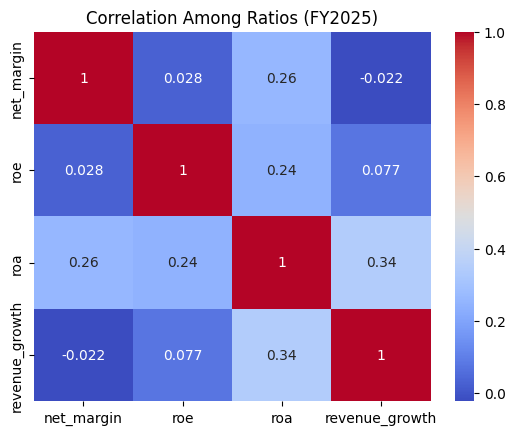

In [ ]:
# Plot the ratio correlation matrix as a heatmap
import seaborn as sns
sns.heatmap(latest[ratio_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Among Ratios (FY2025)")
plt.show()

## Day 3 (PM) — Trend Charts

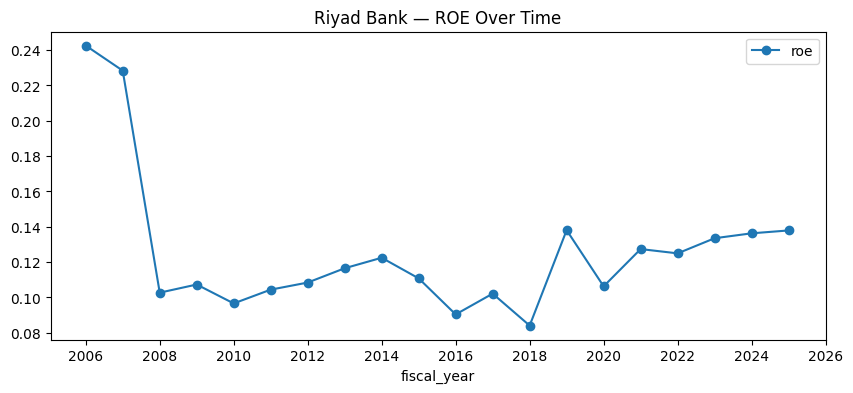

In [ ]:
# Plot one firm's ROE trend over time
one = df[df["ticker"] == 1010].sort_values("fiscal_year")
ax = one.plot(x="fiscal_year", y="roe", marker="o", title="Riyad Bank — ROE Over Time", figsize=(10,4))
min_year = df["fiscal_year"].min()
max_year = df["fiscal_year"].max()
years_to_show = range(min_year, max_year + 1, 2)
ax.set_xticks(years_to_show)
plt.show()

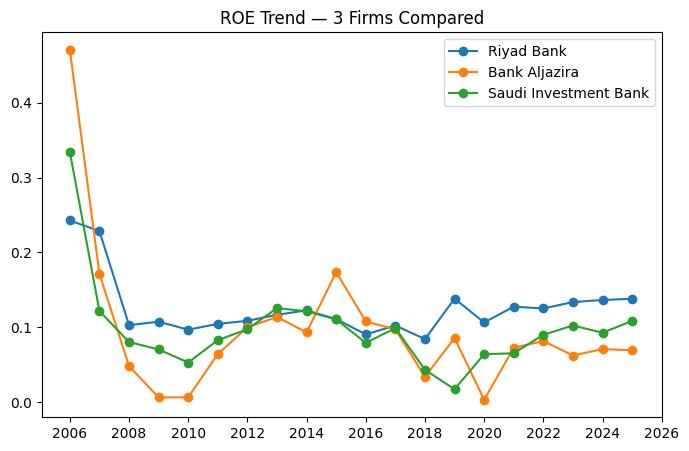

In [ ]:
# Plot and compare ROE trends across three firms
fig, ax = plt.subplots(figsize=(8,5))
for t in [1010, 1020, 1030]:
    d = df[df["ticker"] == t].sort_values("fiscal_year")
    name = d["profile_name"].iloc[-1]
    ax.plot(d["fiscal_year"], d["roe"], marker="o", label=name)
ax.legend()
ax.set_title("ROE Trend — 3 Firms Compared")
min_year = df["fiscal_year"].min()
max_year = df["fiscal_year"].max()
years_to_show = range(min_year, max_year + 1, 2)
ax.set_xticks(years_to_show)
plt.show()

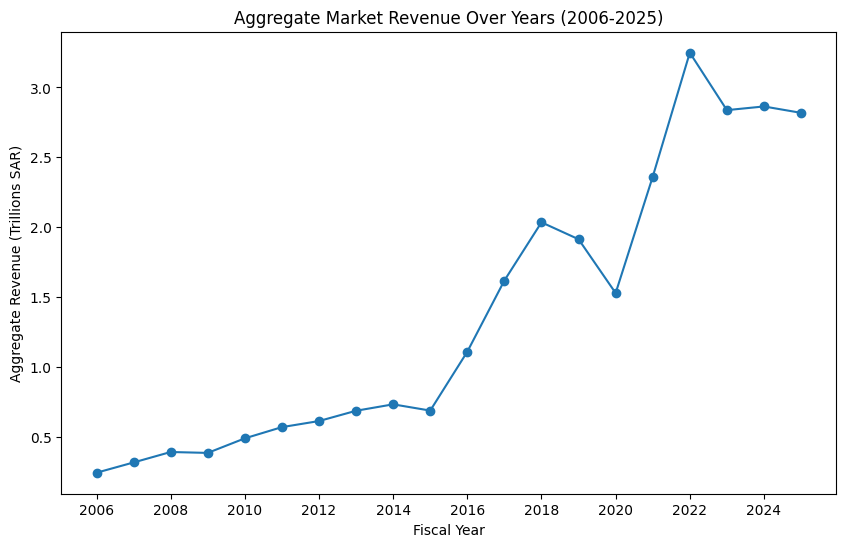

In [ ]:
# Plot aggregate market-wide revenue over time
filtered_df = df[(df['fiscal_year'] >= 2006) & (df['fiscal_year'] <= 2025)]
agg_net_income = filtered_df.groupby('fiscal_year')['revenue'].sum() / 1_000_000_000_000 # Convert to trillions

plt.figure(figsize=(10, 6))
ax = agg_net_income.plot(kind='line', marker='o')
plt.title('Aggregate Market Revenue Over Years (2006-2025)')
plt.xlabel('Fiscal Year')
plt.ylabel('Aggregate Revenue (Trillions SAR)')
min_year_plot = filtered_df["fiscal_year"].min()
max_year_plot = filtered_df["fiscal_year"].max()
years_to_show = range(min_year_plot, max_year_plot + 1, 2)
ax.set_xticks(years_to_show)
plt.show()

## Day 4 (AM) — Screener: Normalize & Score


In [ ]:
# Normalize ratios (z-scores) and rank firms by a weighted quality score
screen = df[df["fiscal_year"] == 2025].copy()
screen = screen.dropna(subset=["roe", "net_margin", "revenue_growth"])

for col in ["roe", "net_margin", "revenue_growth"]:
    screen[col + "_z"] = (screen[col] - screen[col].mean()) / screen[col].std()

screen["quality_score"] = (
    0.4 * screen["roe_z"] +
    0.4 * screen["revenue_growth_z"] +
    0.2 * screen["net_margin_z"]
)
screen.sort_values("quality_score", ascending=False)[
    ["profile_name", "ticker", "profile_sector", "profile_industry", "quality_score"]
].head(10)

,profile_name,ticker,profile_sector,profile_industry,quality_score
728,Saudi Cable Co.,2110,Producer manufacturing,Electrical products,3.46
788,AYYAN Investment Company,2140,Industrial services,Engineering & construction,2.59
2908,Ash-Sharqiyah Development Co.,6060,Process industries,Agricultural commodities/Milling,2.33
2290,"Emaar, The Economic City",4220,Finance,Real estate development,2.23
3556,Group Five Pipe Saudi Ltd.,9523,Non-energy minerals,Steel,1.44
2501,Knowledge Economic City,4310,Finance,Real estate development,1.29
3688,Edarat Communication and Information Technolog...,9557,Technology services,Information technology services,1.12
3493,Rasan Information Technology Co.,8313,Technology services,Packaged software,1.11
671,Miahona Co.,2084,Utilities,Water utilities,1.06
3843,WSM for Information Technology Co.,9595,Technology services,Packaged software,0.94


In [ ]:
# Interactive screener: adjust ratio weights live and re-rank firms
from ipywidgets import interact, FloatSlider

@interact(
    w_roe=FloatSlider(value=0.4, min=0, max=1, step=0.05, description="ROE"),
    w_growth=FloatSlider(value=0.4, min=0, max=1, step=0.05, description="Growth"),
    w_net_margin=FloatSlider(value=0.2, min=0, max=1, step=0.05, description="Net Margin"),
)
def rescore(w_roe, w_growth, w_net_margin):
    total_weight = w_roe + w_growth + w_net_margin
    if total_weight == 0:
        print("At least one weight must be greater than 0.")
        return

    # normalize so weights always sum to 1, regardless of slider positions
    w_roe, w_growth, w_net_margin = (w / total_weight for w in (w_roe, w_growth, w_net_margin))

    score = (
        w_roe * screen["roe_z"]
        + w_growth * screen["revenue_growth_z"]
        + w_net_margin * screen["net_margin_z"]
    )

    result = (
        screen.assign(score=score)
        .sort_values("score", ascending=False)
        .head(10)
    )

    display(
        result[["profile_name", "ticker", "profile_sector", "profile_industry", "score"]]
        .round({"score": 2})
        .reset_index(drop=True)
    )

interactive(children=(FloatSlider(value=0.4, description='ROE', max=1.0, step=0.05), FloatSlider(value=0.4, de…